## ⚙️ 0. Setup Colab

## 📦 1. Imports & Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow :", tf.__version__)
print("GPUs :", tf.config.list_physical_devices("GPU"))

2026-04-19 21:57:53.777311: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776635873.800988    2202 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776635873.808897    2202 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776635873.830115    2202 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776635873.830138    2202 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776635873.830141    2202 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
GPUs : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# ─────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────
CSV_PATH   = '/kaggle/input/datasets/amaurytchoupe/new-esc-50/esc50_augmented.csv'
IMG_DIR    = "/kaggle/input/datasets/amaurytchoupe/new-esc-50/new-esc50-augmented"
MODEL_PATH = "/kaggle/working/spectrogram_model.keras"
DATA_DIR   = "./data/spectrograms"
USE_CSV    = True

IMAGE_SIZE = 300
BATCH_SIZE = 32
EPOCHS_P1  = 50
EPOCHS_P2  = 100
N_HEADS    = 4
KEY_DIM    = 64
BLUR_THRESHOLD = 100

## 📂 2. Chargement des données

In [3]:
def load_from_csv(csv_path, img_dir, image_size):
    """
    Charge les spectrogrammes depuis esc50_augmented.csv.
    Utilise la colonne 'target' directement → pas de re-encodage alphabétique.
    """
    df = pd.read_csv(csv_path, sep=";", dtype={"filename": str, "category": str, "target": int})

    labels = (
        df[["category", "target"]]
        .drop_duplicates()
        .sort_values("target")["category"]
        .tolist()
    )
    print(f"   {len(labels)} classes — ex: 0={labels[0]}, 1={labels[1]}, 49={labels[49]}")

    X, y = [], []
    missing = 0
    for _, row in tqdm(df.iterrows(), total=len(df)):
        fn  = os.path.splitext(row["filename"])[0] + ".png"
        img = cv2.imread(os.path.join(img_dir, fn))
        if img is None:
            missing += 1
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (image_size, image_size))
        X.append(img)
        y.append(int(row["target"]))

    if missing:
        print(f"⚠️  {missing}/{len(df)} images introuvables.")

    return np.array(X, dtype=np.uint8), np.array(y, dtype=np.int32), labels


def load_from_folders(data_dir, image_size):
    labels = sorted(os.listdir(data_dir))
    label2idx = {l: i for i, l in enumerate(labels)}
    X, y = [], []
    for label in labels:
        folder = os.path.join(data_dir, label)
        for fname in tqdm(os.listdir(folder), desc=f"  {label}"):
            img = cv2.imread(os.path.join(folder, fname))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (image_size, image_size))
            X.append(img)
            y.append(label2idx[label])
    return np.array(X, dtype=np.uint8), np.array(y, dtype=np.int32), labels

## ✂️ 3. Split sans Data Leakage

In [4]:
def split_data(X, y, df):
    """
    Split basé sur les fichiers WAV sources, PAS sur les images augmentées.
    Toutes les variantes d'un même WAV restent dans le même split.
    """
    suffixes = ["_original", "_noise", "_shift_fwd", "_shift_bwd",
                "_pitch_up", "_pitch_down", "_speed_up"]

    def get_source(fname):
        for suf in suffixes:
            if suf in fname:
                return fname.split(suf)[0]
        return os.path.splitext(fname)[0].replace(".wav_standard", "")

    df = df.copy()
    df["source"] = df["filename"].apply(get_source)

    source_list    = df["source"].unique()
    source_targets = df.groupby("source")["target"].first()
    strat          = [source_targets[s] for s in source_list]

    src_tv, src_test = train_test_split(
        source_list, test_size=0.10, random_state=42, stratify=strat
    )
    strat_tv = [source_targets[s] for s in src_tv]
    src_train, src_val = train_test_split(
        src_tv, test_size=0.111, random_state=42, stratify=strat_tv
    )

    src_train = set(src_train)
    src_val   = set(src_val)
    src_test  = set(src_test)

    train_mask = df["source"].isin(src_train).values
    val_mask   = df["source"].isin(src_val).values
    test_mask  = df["source"].isin(src_test).values

    X_train, y_train = X[train_mask], y[train_mask]
    X_val,   y_val   = X[val_mask],   y[val_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    print(f"   Sources uniques : {len(source_list)}")
    print(f"   Train : {len(X_train)} images ({len(src_train)} sources)")
    print(f"   Val   : {len(X_val)} images ({len(src_val)} sources)")
    print(f"   Test  : {len(X_test)} images ({len(src_test)} sources)")
    print("   ✅ Aucune variante du même WAV ne chevauche train/val/test")

    return X_train, X_val, X_test, y_train, y_val, y_test

## 🔄 4. Générateurs d'augmentation

In [5]:
def spec_augment(image):
    """
    SpecAugment : masquage aléatoire de bandes de fréquences et de temps.
    Technique standard en audio deep learning (Park et al., 2019).
    """
    img = image.copy()
    h, w = img.shape[:2]

    f  = np.random.randint(0, max(1, int(h * 0.20)))
    f0 = np.random.randint(0, max(1, h - f))
    img[f0:f0 + f, :] = 0

    t  = np.random.randint(0, max(1, int(w * 0.20)))
    t0 = np.random.randint(0, max(1, w - t))
    img[:, t0:t0 + t] = 0

    return img


def augment_and_preprocess(image):
    """Applique SpecAugment puis le preprocessing EfficientNet."""
    image = spec_augment(image)
    return preprocess_input(image)


def build_generators(X_train, y_train, X_val, y_val, n_classes):
    y_tr = tf.keras.utils.to_categorical(y_train, n_classes)
    y_vl = tf.keras.utils.to_categorical(y_val,   n_classes)

    train_aug = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=5,
        width_shift_range=0.10,
        height_shift_range=0.05,
        zoom_range=0.10,
        brightness_range=[0.80, 1.20],
        fill_mode="nearest",
    )
    val_aug = ImageDataGenerator(preprocessing_function=preprocess_input)
    return (
        train_aug.flow(X_train, y_tr, batch_size=BATCH_SIZE, shuffle=True,  seed=42),
        val_aug.flow(X_val,   y_vl, batch_size=BATCH_SIZE, shuffle=False),
    )

## 🧠 5. Architecture CNN + Multi-Head Attention

In [6]:
def build_model(n_classes, image_size):
    """
    Input (224×224×3)
        ↓ EfficientNetB0 → feature maps (7×7×1280)
        ↓ Reshape → séquence 49 tokens × 1280 dims
        ↓ Dense projection → 256 dims
        ↓ Multi-Head Self-Attention (4 têtes)
        ↓ Connexion résiduelle + LayerNorm
        ↓ Feed-Forward (GELU)
        ↓ GlobalAveragePooling1D
        ↓ Dense → Softmax
    """
    base = EfficientNetB3(
        include_top=False,
        weights="imagenet",
        input_shape=(image_size, image_size, 3),
    )
    base.trainable = False

    inputs = tf.keras.Input(shape=(image_size, image_size, 3))
    x = base(inputs, training=False)

    _, H, W, C = tf.keras.backend.int_shape(x)
    x_seq = layers.Reshape((H * W, C))(x)

    x_proj = layers.Dense(256, use_bias=False)(x_seq)
    x_proj = layers.LayerNormalization()(x_proj)

    attn = layers.MultiHeadAttention(
        num_heads=N_HEADS, key_dim=KEY_DIM, dropout=0.1
    )(x_proj, x_proj)

    x_a = layers.Add()([x_proj, attn])
    x_a = layers.LayerNormalization()(x_a)

    x_ff = layers.Dense(512, activation="gelu")(x_a)
    x_ff = layers.Dropout(0.2)(x_ff)
    x_ff = layers.Dense(256)(x_ff)
    x_a  = layers.Add()([x_a, x_ff])
    x_a  = layers.LayerNormalization()(x_a)

    x_out = layers.GlobalAveragePooling1D()(x_a)
    x_out = layers.Dense(256, activation="relu")(x_out)
    x_out = layers.Dropout(0.2)(x_out)
    x_out = layers.Dense(128, activation="relu")(x_out)
    x_out = layers.Dropout(0.1)(x_out)
    outputs = layers.Dense(n_classes, activation="softmax")(x_out)

    return models.Model(inputs, outputs, name="SpectrogramCNNAttention"), base

## 🏋️ 6. Entraînement en 2 phases

In [7]:
def train_phase1(model, train_gen, val_gen):
    print("\n" + "="*55)
    print("PHASE 1 : Attention + tête (backbone gelé)")
    print("="*55)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model.fit(
        train_gen, epochs=EPOCHS_P1, validation_data=val_gen,
        callbacks=[
            EarlyStopping(monitor="val_accuracy", patience=12, restore_best_weights=True),
            ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=4, verbose=1),
            ModelCheckpoint(MODEL_PATH, monitor="val_accuracy", save_best_only=True, verbose=1),
        ],
        verbose=1,
    )


def train_phase2(model, base, train_gen, val_gen):
    print("\n" + "="*55)
    print("PHASE 2 : Fine-tuning (20 dernières couches, BN gelées)")
    print("="*55)
    base.trainable = True
    for layer in base.layers[:-20]:
        layer.trainable = False

    # Fix BatchNormalization — garde les stats stables d'ImageNet
    for layer in base.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(5e-6),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model.fit(
        train_gen, epochs=EPOCHS_P2, validation_data=val_gen,
        callbacks=[
            EarlyStopping(monitor="val_accuracy", patience=15, restore_best_weights=True),
            ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=6, verbose=1),
            ModelCheckpoint(MODEL_PATH, monitor="val_accuracy", save_best_only=True, verbose=1),
        ],
        verbose=1,
    )

## 📊 7. Évaluation & Visualisation

In [8]:
def evaluate_model(model, X_test, y_test, labels):
    n = len(labels)
    test_gen = ImageDataGenerator(preprocessing_function=preprocess_input).flow(
        X_test, tf.keras.utils.to_categorical(y_test, n),
        batch_size=BATCH_SIZE, shuffle=False
    )
    loss, acc = model.evaluate(test_gen, verbose=1)
    print(f"\n✅ Test Accuracy : {acc*100:.2f}%  |  Loss : {loss:.4f}")

    y_pred = np.argmax(model.predict(test_gen), axis=1)
    print(classification_report(y_test, y_pred, target_names=labels))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(18, 16))
    sns.heatmap(cm, annot=(n <= 20), fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title("Matrice de Confusion — Spectrogrammes")
    plt.xticks(rotation=45, ha="right", fontsize=7)
    plt.yticks(fontsize=7)
    plt.tight_layout()
    plt.savefig("confusion_spectrogram.png", dpi=150)
    plt.show()


def plot_history(h1, h2):
    acc   = h1.history["accuracy"]     + h2.history["accuracy"]
    val   = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    loss  = h1.history["loss"]         + h2.history["loss"]
    vloss = h1.history["val_loss"]     + h2.history["val_loss"]
    sep   = len(h1.history["accuracy"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, tr, vl, title in zip(axes, [acc, loss], [val, vloss], ["Exactitude", "Perte"]):
        ax.plot(tr, label="Train")
        ax.plot(vl, label="Validation")
        ax.axvline(sep, color="red", ls="--", label="Fine-tuning")
        ax.set_title(f"{title} — Spectrogrammes")
        ax.set_xlabel("Époque")
        ax.legend()
    plt.tight_layout()
    plt.savefig("training_curves_spectrogram.png", dpi=150)
    plt.show()

## 🧹 8. Data Cleaning — Loss-Based

In [9]:
def find_high_loss_images(model, df, img_dir, labels, top_n=50):
    """Identifie les top_n images avec le loss le plus élevé."""
    print(f"\n🔍 Calcul du loss individuel pour {len(df)} images...")
    losses = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        fn   = os.path.splitext(row["filename"])[0] + ".wav_standard"
        path = os.path.join(img_dir, fn)
        img  = cv2.imread(path)
        if img is None:
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_rgb = cv2.resize(img_rgb, (IMAGE_SIZE, IMAGE_SIZE))
        x       = preprocess_input(img_rgb.astype(np.float32))
        x       = np.expand_dims(x, axis=0)

        target  = int(row["target"])
        y_true  = tf.keras.utils.to_categorical([target], num_classes=len(labels))
        y_pred  = model.predict(x, verbose=0)
        loss    = tf.keras.losses.categorical_crossentropy(y_true, y_pred).numpy()[0]

        losses.append({
            "filename": fn, "path": path, "category": row["category"],
            "target": target, "loss": float(loss),
            "pred": labels[int(np.argmax(y_pred))], "conf": float(np.max(y_pred)),
        })

    df_loss = pd.DataFrame(losses).sort_values("loss", ascending=False)
    print(f"   Loss moyen : {df_loss['loss'].mean():.3f} | max : {df_loss['loss'].max():.3f}")
    return df_loss.head(top_n)


def inspect_and_clean(df_high_loss, output_csv="images_to_delete.csv", blur_threshold=BLUR_THRESHOLD):
    """Affiche la grille des images à haut loss avec score de flou."""
    n = len(df_high_loss)
    ncols = 10
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(25, nrows * 3))
    axes = axes.flatten()

    blur_scores = []
    for i, (_, row) in enumerate(df_high_loss.iterrows()):
        img = cv2.imread(row["path"])
        if img is None:
            axes[i].axis("off"); blur_scores.append(0); continue

        gray       = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
        is_blurry  = blur_score < blur_threshold
        blur_scores.append(blur_score)

        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        color = "red" if is_blurry else "green"
        axes[i].set_title(
            f"Loss: {row['loss']:.2f}\nVrai: {row['category']}\nPréd: {row['pred']}\nFlou: {blur_score:.0f}",
            fontsize=6, color=color
        )
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    df_high_loss = df_high_loss.copy()
    df_high_loss["blur_score"] = blur_scores
    df_high_loss["is_blurry"]  = df_high_loss["blur_score"] < blur_threshold

    plt.suptitle(f"Top {n} images — 🔴 Floue | 🟢 Nette", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("high_loss_images.png", dpi=120)
    plt.show()

    to_delete = df_high_loss[df_high_loss["is_blurry"]].copy()
    to_delete.to_csv(output_csv, index=False)
    print(f"\n📋 {len(to_delete)} images floues → {output_csv}")
    return to_delete


def delete_flagged_images(csv_path="images_to_delete.csv", confirm=True):
    """Supprime physiquement les images listées dans le CSV."""
    if not os.path.exists(csv_path):
        print(f"❌ Fichier introuvable : {csv_path}"); return

    df = pd.read_csv(csv_path)
    print(f"\n⚠️  {len(df)} images vont être supprimées.")

    if confirm:
        rep = input("Confirmer ? (oui/non) : ").strip().lower()
        if rep != "oui":
            print("Annulé."); return

    deleted, errors = 0, 0
    for _, row in df.iterrows():
        if os.path.exists(row["path"]):
            os.remove(row["path"]); deleted += 1
        else:
            errors += 1
    print(f"\n✅ {deleted} supprimés | {errors} introuvables")

## 🚀 9. Lancement de l'entraînement

In [10]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

CSV_PATH   = '/kaggle/input/datasets/amaurytchoupe/new-esc-50/esc50_augmented.csv'
IMG_DIR    = "/kaggle/input/datasets/amaurytchoupe/new-esc-50/new-esc50-augmented"
df = pd.read_csv(CSV_PATH, sep=";", dtype={"filename": str, "category": str, "target": int})

labels = (
    df[["category", "target"]]
    .drop_duplicates()
    .sort_values("target")["category"]
    .tolist()
)
n_classes = len(labels)
print(f"{n_classes} classes")

# ── Split par source sans charger les images ───────────────────────────────
suffixes = ["_original","_noise","_shift_fwd","_shift_bwd",
            "_pitch_up","_pitch_down","_speed_up"]

def get_source(fname):
    for suf in suffixes:
        if suf in fname:
            return fname.split(suf)[0]
    return os.path.splitext(fname)[0]

df["source"] = df["filename"].apply(get_source)
df["filepath"] = df["filename"].apply(lambda f: os.path.join(IMG_DIR, f))

source_list    = df["source"].unique()
source_targets = df.groupby("source")["target"].first()
strat          = [source_targets[s] for s in source_list]

src_tv, src_test = train_test_split(source_list, test_size=0.10, random_state=42, stratify=strat)
src_train, src_val = train_test_split(src_tv, test_size=0.111, random_state=42,
                                       stratify=[source_targets[s] for s in src_tv])

df_train = df[df["source"].isin(src_train)]
df_val   = df[df["source"].isin(src_val)]
df_test  = df[df["source"].isin(src_test)]

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

# ── Générateur tf.data (lit depuis le disque, pas de RAM) ─────────────────
def make_dataset(df_split, shuffle=True, augment=False):
    paths   = df_split["filepath"].values
    targets = df_split["target"].values

    def load_and_preprocess(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, [300, 300])
        img = tf.cast(img, tf.float32)
        img = preprocess_input(img)
        label = tf.one_hot(label, n_classes)
        return img, label

    def augment_fn(img, label):
        img = tf.image.random_brightness(img, 0.2)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, targets))
    if shuffle:
        ds = ds.shuffle(buffer_size=2000, seed=42)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(32).prefetch(tf.data.AUTOTUNE)
    return ds

train_gen = make_dataset(df_train, shuffle=True,  augment=True)
val_gen   = make_dataset(df_val,   shuffle=False, augment=False)
test_gen  = make_dataset(df_test,  shuffle=False, augment=False)

print("✅ Générateurs prêts — images lues depuis le disque")

50 classes
Train: 15800 | Val: 2128 | Test: 2072


I0000 00:00:1776635883.523858    2202 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776635883.529175    2202 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✅ Générateurs prêts — images lues depuis le disque


In [11]:
# Phase 1 — backbone gelé
model, base = build_model(n_classes, IMAGE_SIZE)
model.summary()
def train_phase1(model, train_gen, val_gen):
    print("\n" + "="*55)
    print("PHASE 1 : Attention + tête (backbone gelé)")
    print("="*55)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(8e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS_P1,
        callbacks=[
            EarlyStopping(monitor="val_accuracy", patience=20, restore_best_weights=True),
            ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=4, verbose=1),
            ModelCheckpoint(MODEL_PATH, monitor="val_accuracy", save_best_only=True, verbose=1),
        ],
        verbose=1,
    )

h1 = train_phase1(model, train_gen, val_gen)

Model: "SpectrogramCNNAttention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb3      │ (None, 10, 10,    │ 10,783,535 │ input_layer_1[0]… │
│ (Functional)        │ 1536)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 100, 1536) │          0 │ efficientnetb3[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 100, 256)  │    393,216 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 100, 256)  │        512 │ dense[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 256)  │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 100, 256)  │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 256)  │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 100, 512)  │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 100, 512)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 100, 256)  │    131,328 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 100, 256)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 256)  │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     65,792 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 50)        │      6,450 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,809,505 (45.05 MB)

 Trainable params: 1,025,970 (3.91 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

...

493/494 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.4669 - loss: 1.9260

2026-04-19 22:00:22.197188: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 22:00:22.347351: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 22:00:22.749146: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 22:00:22.897175: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 22:00:23.730970: E external/local_xla/xla/stream_

494/494 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.4669 - loss: 1.9262

2026-04-19 22:01:10.056173: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 22:01:10.200979: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 22:01:10.570642: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 22:01:10.717890: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 22:01:10.874997: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.25188, saving model to /kaggle/working/spectrogram_model.keras
494/494 ━━━━━━━━━━━━━━━━━━━━ 194s 280ms/step - accuracy: 0.4669 - loss: 1.9263 - val_accuracy: 0.2519 - val_loss: 3.5465 - learning_rate: 8.0000e-04
Epoch 2/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.6105 - loss: 1.3452
Epoch 2: val_accuracy improved from 0.25188 to 0.35855, saving model to /kaggle/working/spectrogram_model.keras
494/494 ━━━━━━━━━━━━━━━━━━━━ 75s 152ms/step - accuracy: 0.6106 - loss: 1.3448 - val_accuracy: 0.3586 - val_loss: 2.7391 - learning_rate: 8.0000e-04
Epoch 3/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.7242 - loss: 0.9366
Epoch 3: val_accuracy improved from 0.35855 to 0.42152, saving model to /kaggle/working/spectrogram_model.keras
494/494 ━━━━━━━━━━━━━━━━━━━━ 78s 158ms/step - accuracy: 0.7242 - loss: 0.9365 - val_accuracy: 0.4215 - val_loss: 2.4585 - learning_rate: 8.0000e-04
Epoch 4/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 0s 14

In [13]:
# Phase 2 — fine-tuning
model = tf.keras.models.load_model(MODEL_PATH)
base  = model.get_layer("efficientnetb3")
def train_phase2(model, base, train_gen, val_gen):
    print("\n" + "="*55)
    print("PHASE 2 : Fine-tuning (20 dernières couches, BN gelées)")
    print("="*55)
    base.trainable = True
    for layer in base.layers[:-80]:
        layer.trainable = False
    for layer in base.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS_P2,
        callbacks=[
            EarlyStopping(monitor="val_accuracy", patience=15, restore_best_weights=True),
            ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=6, verbose=1),
            ModelCheckpoint(MODEL_PATH, monitor="val_accuracy", save_best_only=True, verbose=1),
        ],
        verbose=1,
    )

h2 = train_phase2(model, base, train_gen, val_gen)


PHASE 2 : Fine-tuning (20 dernières couches, BN gelées)
Epoch 1/100
494/494 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.7509 - loss: 0.8320
Epoch 1: val_accuracy improved from -inf to 0.78430, saving model to /kaggle/working/spectrogram_model.keras
494/494 ━━━━━━━━━━━━━━━━━━━━ 184s 276ms/step - accuracy: 0.7512 - loss: 0.8313 - val_accuracy: 0.7843 - val_loss: 0.7358 - learning_rate: 1.0000e-05
Epoch 2/100
494/494 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.8804 - loss: 0.4057
Epoch 2: val_accuracy improved from 0.78430 to 0.81532, saving model to /kaggle/working/spectrogram_model.keras
494/494 ━━━━━━━━━━━━━━━━━━━━ 95s 192ms/step - accuracy: 0.8805 - loss: 0.4054 - val_accuracy: 0.8153 - val_loss: 0.6241 - learning_rate: 1.0000e-05
Epoch 3/100
494/494 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9194 - loss: 0.2494
Epoch 3: val_accuracy improved from 0.81532 to 0.82942, saving model to /kaggle/working/spectrogram_model.keras
494/494 ━━━━━━━━━━━━━━━━━━━━ 102s 206ms/step -

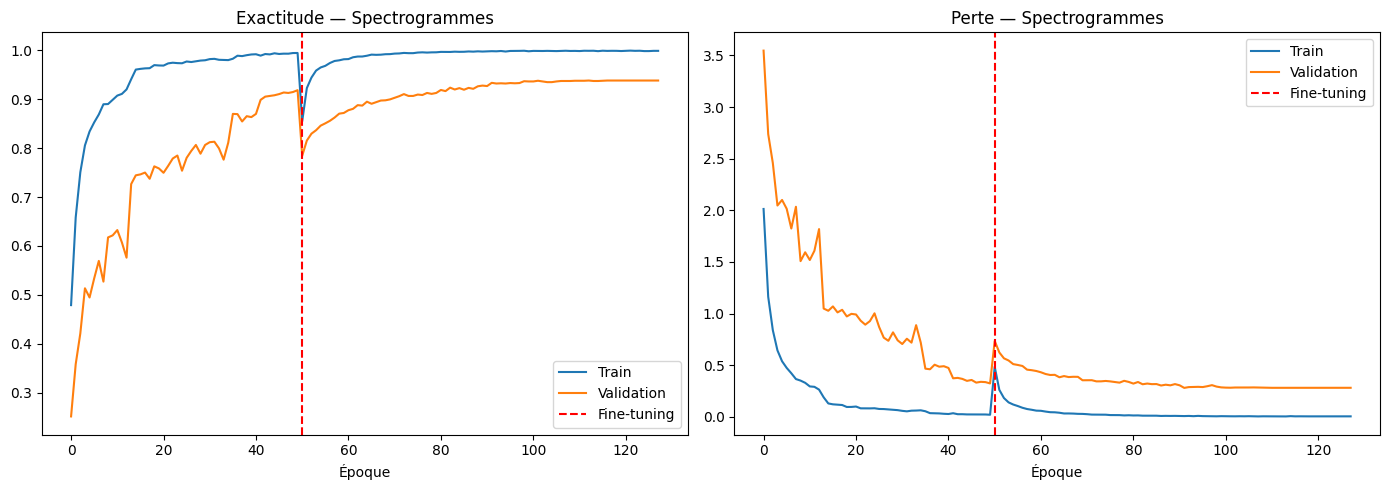

In [14]:
# Courbes d'entraînement
plot_history(h1, h2)

## 📈 10. Évaluation finale

In [15]:
loss, acc = model.evaluate(test_gen, verbose=1)
print(f"\n✅ Test Accuracy : {acc*100:.2f}%")
print(f"💾 Modèle sauvegardé → {MODEL_PATH}")

65/65 ━━━━━━━━━━━━━━━━━━━━ 15s 231ms/step - accuracy: 0.9307 - loss: 0.3786

✅ Test Accuracy : 93.34%
💾 Modèle sauvegardé → /kaggle/working/spectrogram_model.keras


## 🧹 11. Data Cleaning post-entraînement

In [ ]:
best_model = tf.keras.models.load_model(MODEL_PATH)
df_csv = pd.read_csv(CSV_PATH, sep=";",
                     dtype={"filename": str, "category": str, "target": int})

# Top 50 images avec le loss le plus élevé
df_high_loss = find_high_loss_images(best_model, df_csv, IMG_DIR, labels, top_n=50)

# Inspection visuelle + détection de flou
to_delete = inspect_and_clean(df_high_loss, output_csv="images_to_delete.csv",
                              blur_threshold=BLUR_THRESHOLD)

# Décommenter pour supprimer physiquement les fichiers
# ⚠️  IRRÉVERSIBLE — vérifier high_loss_images.png avant
# delete_flagged_images("images_to_delete.csv", confirm=True)